<a href="https://colab.research.google.com/github/Enter4567/Data-Analytics-Projects/blob/main/Employee-Attrition-Prediction/Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ML(data cleaning, data modeling, data preprocessing, EDA)
#check if it is regressor or classification
#1.linear regression(simple, multiple(x)), logistic regression, PCA, KNN, K_means,
#Decision tree,random forest, Gradiant Descent, XGBoost, Naiuse Buyers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df=pd.read_csv("/content/train_dataset.csv")
d1=pd.read_csv("/content/train_salaries.csv")

In [ ]:
df=(pd.merge(df,d1,on="jobId"))

In [ ]:
df.tail()

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis
71551,JOB1362684479238,COMP37,CTO,HIGH_SCHOOL,NONE,HEALTH,19.0,28.0
71552,JOB1362684479239,COMP16,VICE_PRESIDENT,BACHELORS,LITERATURE,AUTO,22.0,34.0
71553,JOB1362684479240,COMP30,SENIOR,NONE,NONE,SERVICE,5.0,49.0
71554,JOB1362684479241,COMP27,JUNIOR,MASTERS,NONE,HEALTH,1.0,18.0
71555,JOB1362684479242,COMP5,MANAGER,HIGH_SC,NaN,NaN,NaN,NaN


In [ ]:
df.nunique()

,0
jobId,71556
companyId,63
jobType,8
degree,6
major,9
industry,7
yearsExperience,25
milesFromMetropolis,100
salary,263


In [ ]:
df.columns

Index(['jobId', 'companyId', 'jobType', 'degree', 'major', 'industry',
       'yearsExperience', 'milesFromMetropolis', 'salary'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71556 entries, 0 to 71555
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   jobId                71556 non-null  object 
 1   companyId            71556 non-null  object 
 2   jobType              71556 non-null  object 
 3   degree               71556 non-null  object 
 4   major                71555 non-null  object 
 5   industry             71555 non-null  object 
 6   yearsExperience      71555 non-null  float64
 7   milesFromMetropolis  71555 non-null  float64
 8   salary               71556 non-null  float64
dtypes: float64(3), object(6)
memory usage: 4.9+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
yearsExperience,71555.0,11.929537,7.205275,0.0,6.0,12.0,18.0,24.0
milesFromMetropolis,71555.0,49.405143,28.793177,0.0,25.0,49.0,74.0,99.0
salary,71556.0,115.848203,38.617989,0.0,88.0,114.0,141.0,292.0


In [ ]:
df.isnull().sum()

,0
jobId,0
companyId,0
jobType,0
degree,0
major,1
industry,1
yearsExperience,1
milesFromMetropolis,1


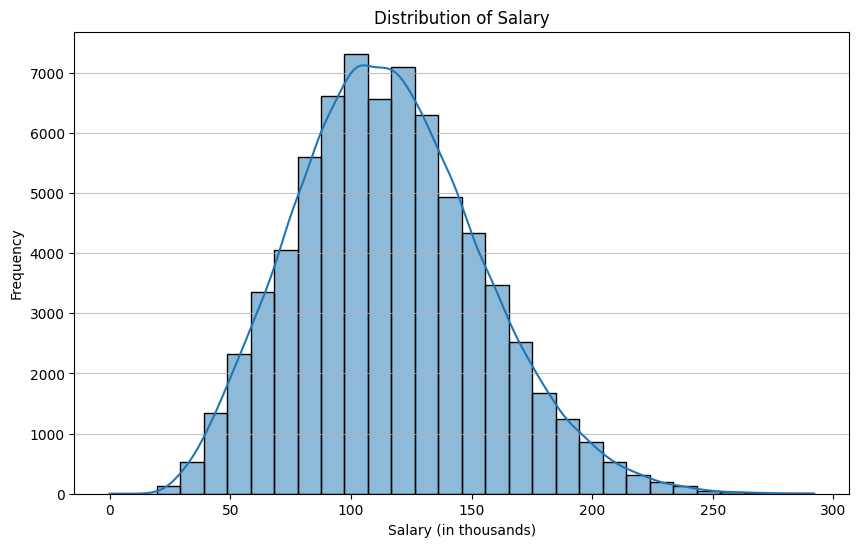

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], bins=30, kde=True)
plt.title('Distribution of Salary')
plt.xlabel('Salary (in thousands)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

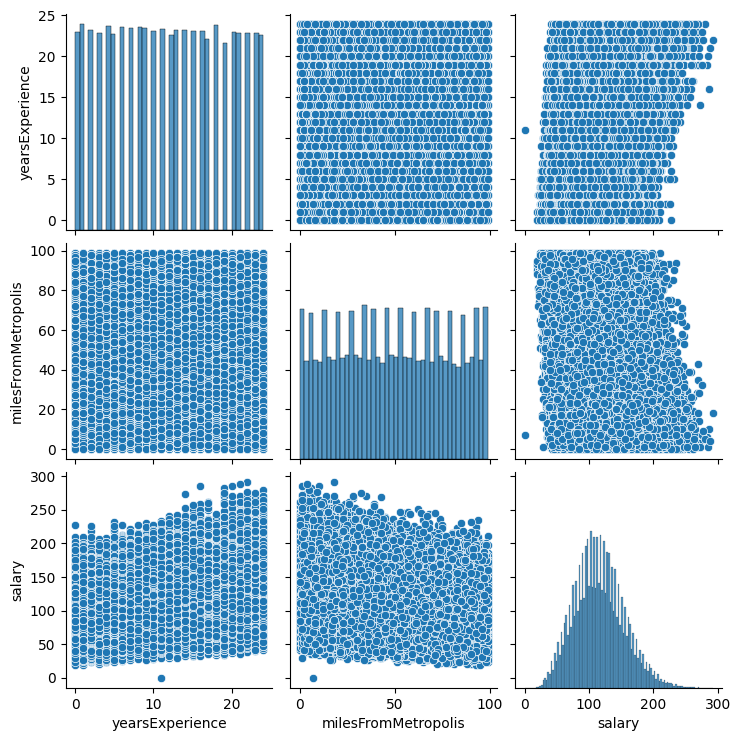

In [ ]:
sns.pairplot(df)

In [ ]:
df.dtypes

,0
jobId,object
companyId,object
jobType,object
degree,object
major,object
industry,object
yearsExperience,float64
milesFromMetropolis,float64
salary,float64


In [ ]:
df.isnull()

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis,salary
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
71551,False,False,False,False,False,False,False,False,False
71552,False,False,False,False,False,False,False,False,False
71553,False,False,False,False,False,False,False,False,False
71554,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
#X=df.drop(columns='salary')
X=df[['yearsExperience','milesFromMetropolis']]
y=df['salary']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.03, random_state=42)
print('x_train size:{}, x_test_size:{}'.format(X_train.shape, X_test.shape))

x_train size:(69409, 2), x_test_size:(2147, 2)


In [ ]:
#df = df.drop(df.index[-1])
#print("Last row dropped from df. Remaining rows:", df.shape[0])

In [ ]:
df.isnull().sum()

,0
jobId,0
companyId,0
jobType,0
degree,0
major,1
industry,1
yearsExperience,1
milesFromMetropolis,1
salary,0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNN Score:", knn.score(X_test, y_test))


KNN Score: 0.10000620165705354


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log = LogisticRegression(max_iter=500)
log.fit(X_train, y_train)

y_pred = log.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.010945505356311131


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.50135581 0.49864419]


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

print("Cluster centers:\n", kmeans.cluster_centers_)


Cluster centers:
 [[11.96533084 50.49853836]
 [12.00203179 16.49521298]
 [11.95925163 83.54795601]]


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.01071262226362366


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

print("Score:", dt.score(X_test, y_test))


Score: 0.23105835918311957


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

print("Score:", rf.score(X_test, y_test))


Score: 0.23099713539933342


In [ ]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01)
sgd.fit(X_train, y_train)

print("Score:", sgd.score(X_test, y_test))


Score: -2.5005345199283642e+23


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

dt_params = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "splitter": ["best", "random"],
    "max_depth": [3, 5, 7, 10, None]
}

dt = DecisionTreeRegressor(random_state=42)

dt_cv = GridSearchCV(dt, dt_params, cv=5, n_jobs=-1) # Added n_jobs=-1 for faster execution
dt_cv.fit(X_train, y_train)

print("Best Params:", dt_cv.best_params_)
print("Score:", dt_cv.score(X_test, y_test))

NameError: name 'X_train' is not defined